# Step 2 Method Comparison: Logistic Regression vs Label Spreading

Compare the two PULearningPC Step 2 implementations by accuracy, then benchmark the winner against baseline models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [2]:
# Load all final results from both methods
lr_dir = Path('experiment_results')
ls_dir = Path('experiment_results_label_spreading')

datasets = ['cora', 'citeseer', 'mnist', 'pubmed', 'twitch']

def load_final_results(directory, method_name):
    """Load final results, filter successful runs, return best per dataset."""
    all_results = []
    for ds in datasets:
        fpath = directory / f'{ds}_final_results.csv'
        if fpath.exists():
            df = pd.read_csv(fpath)
            df['dataset'] = ds
            df['method'] = method_name
            all_results.append(df)
    if all_results:
        return pd.concat(all_results, ignore_index=True)
    return pd.DataFrame()

df_lr = load_final_results(lr_dir, 'Logistic Regression')
df_ls = load_final_results(ls_dir, 'Label Spreading')

print(f"Logistic Regression: {len(df_lr)} total rows, datasets: {df_lr['dataset'].unique().tolist()}")
print(f"Label Spreading: {len(df_ls)} total rows, datasets: {df_ls['dataset'].unique().tolist()}")

Logistic Regression: 28800 total rows, datasets: ['cora', 'citeseer', 'mnist', 'pubmed', 'twitch']
Label Spreading: 28800 total rows, datasets: ['cora', 'citeseer', 'mnist', 'pubmed', 'twitch']


In [3]:
# Filter only successful runs
df_lr_ok = df_lr[df_lr['status'] == 'success'].copy()
df_ls_ok = df_ls[df_ls['status'] == 'success'].copy()

print(f"Successful runs — LR: {len(df_lr_ok)}, LS: {len(df_ls_ok)}")
print(f"\nSuccess rate — LR: {len(df_lr_ok)/len(df_lr)*100:.1f}%, LS: {len(df_ls_ok)/len(df_ls)*100:.1f}%")

Successful runs — LR: 16869, LS: 16799

Success rate — LR: 58.6%, LS: 58.3%


## 1. Best Step 2 Accuracy per Dataset (each method's best configuration)

In [4]:
# Get best accuracy per dataset for each method (averaged across runs for same config)
config_cols = ['num_particles', 'cluster_strategy', 'positive_cluster_threshold',
               'movement_strategy', 'initialization_strategy', 'avg_node_pot_threshold']

def best_config_per_dataset(df, method_name):
    """For each dataset, find the config with highest mean step2_accuracy across runs."""
    results = []
    for ds in df['dataset'].unique():
        ds_df = df[df['dataset'] == ds]
        # Group by config, average across runs
        grouped = ds_df.groupby(config_cols).agg(
            mean_accuracy=('step2_accuracy', 'mean'),
            std_accuracy=('step2_accuracy', 'std'),
            mean_f1=('step2_f1', 'mean'),
            mean_precision=('step2_precision', 'mean'),
            mean_recall=('step2_recall', 'mean'),
            n_runs=('run_id', 'count')
        ).reset_index()
        
        # Only consider configs with at least 2 runs for robustness
        grouped = grouped[grouped['n_runs'] >= 2]
        if len(grouped) == 0:
            grouped = ds_df.groupby(config_cols).agg(
                mean_accuracy=('step2_accuracy', 'mean'),
                std_accuracy=('step2_accuracy', 'std'),
                mean_f1=('step2_f1', 'mean'),
                mean_precision=('step2_precision', 'mean'),
                mean_recall=('step2_recall', 'mean'),
                n_runs=('run_id', 'count')
            ).reset_index()
        
        best = grouped.loc[grouped['mean_accuracy'].idxmax()]
        results.append({
            'dataset': ds,
            'method': method_name,
            'accuracy': best['mean_accuracy'],
            'std': best['std_accuracy'] if not pd.isna(best['std_accuracy']) else 0,
            'f1': best['mean_f1'],
            'precision': best['mean_precision'],
            'recall': best['mean_recall'],
            'n_runs': best['n_runs'],
            'config': {c: best[c] for c in config_cols}
        })
    return pd.DataFrame(results)

best_lr = best_config_per_dataset(df_lr_ok, 'Logistic Regression')
best_ls = best_config_per_dataset(df_ls_ok, 'Label Spreading')

comparison = pd.concat([best_lr, best_ls], ignore_index=True)
print("=== Best Step 2 Accuracy per Dataset ===")
pivot = comparison.pivot(index='dataset', columns='method', values='accuracy')
pivot['winner'] = pivot.apply(lambda r: 'Label Spreading' if r.get('Label Spreading', 0) > r.get('Logistic Regression', 0) else 'Logistic Regression', axis=1)
pivot['diff'] = (pivot.get('Label Spreading', 0) - pivot.get('Logistic Regression', 0)).abs()
print(pivot.round(4).to_string())
print(f"\nLabel Spreading wins: {(pivot['winner'] == 'Label Spreading').sum()}/{len(pivot)}")

=== Best Step 2 Accuracy per Dataset ===
method    Label Spreading  Logistic Regression               winner    diff
dataset                                                                    
citeseer           0.7757               0.8423  Logistic Regression  0.0666
cora               0.8550               0.8107      Label Spreading  0.0442
mnist              0.8042               0.7330      Label Spreading  0.0712
pubmed             0.7564               0.5684      Label Spreading  0.1881
twitch             0.5309               0.5887  Logistic Regression  0.0577

Label Spreading wins: 3/5


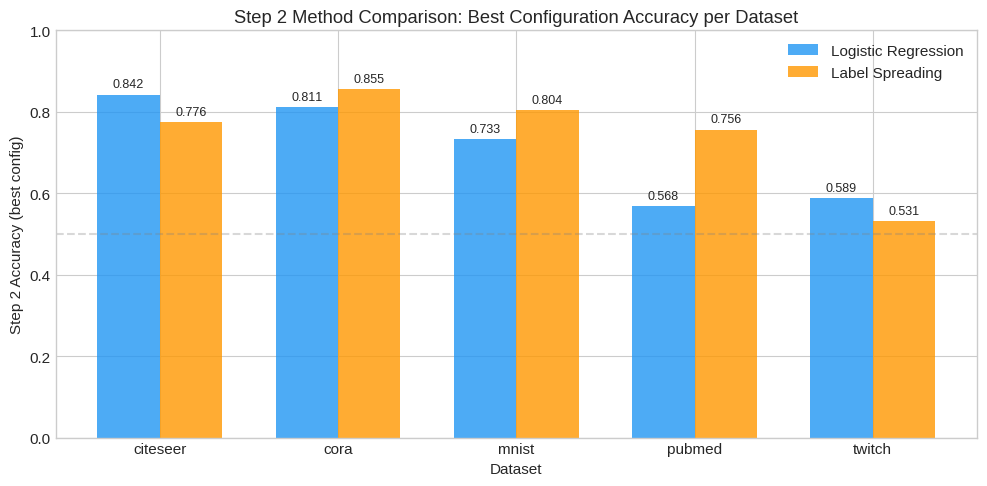

In [5]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(pivot.index))
width = 0.35

bars1 = ax.bar(x - width/2, pivot.get('Logistic Regression', pd.Series([0]*len(x))), 
               width, label='Logistic Regression', color='#2196F3', alpha=0.8)
bars2 = ax.bar(x + width/2, pivot.get('Label Spreading', pd.Series([0]*len(x))), 
               width, label='Label Spreading', color='#FF9800', alpha=0.8)

ax.set_xlabel('Dataset')
ax.set_ylabel('Step 2 Accuracy (best config)')
ax.set_title('Step 2 Method Comparison: Best Configuration Accuracy per Dataset')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)

for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 2. Comparison Against Baselines

Now compare the winning PULearningPC method against all baseline models on phase2_accuracy.

In [6]:
# Load baseline results
df_baseline = pd.read_csv('baseline_results_full.csv')
print(f"Baseline models: {df_baseline['model'].unique().tolist()}")
print(f"Datasets: {df_baseline['dataset'].unique().tolist()}")
print(f"Percent positive values: {df_baseline['percent_positive'].unique().tolist()}")

Baseline models: ['RCSVM', 'CCRNE', 'PU_LP', 'MCLS', 'LP_PUL']
Datasets: ['cora', 'citeseer', 'mnist', 'twitch', 'pubmed']
Percent positive values: [0.01, 0.25]


In [7]:
# Use percent_positive=0.25 for comparison (more labeled data = fairer comparison)
# since our experiments use ~25% positive labeling
df_base_25 = df_baseline[df_baseline['percent_positive'] == 0.25].copy()
df_base_01 = df_baseline[df_baseline['percent_positive'] == 0.01].copy()

# Prepare PULearningPC best results for comparison
# Determine winner method
lr_mean = best_lr['accuracy'].mean() if len(best_lr) > 0 else 0
ls_mean = best_ls['accuracy'].mean() if len(best_ls) > 0 else 0

winner_name = 'Label Spreading' if ls_mean > lr_mean else 'Logistic Regression'
winner_df = best_ls if ls_mean > lr_mean else best_lr

print(f"Overall winner: {winner_name} (mean accuracy: {max(lr_mean, ls_mean):.4f} vs {min(lr_mean, ls_mean):.4f})")
print(f"\n--- Winner's accuracy per dataset ---")
for _, row in winner_df.iterrows():
    print(f"  {row['dataset']}: {row['accuracy']:.4f}")

Overall winner: Label Spreading (mean accuracy: 0.7444 vs 0.7086)

--- Winner's accuracy per dataset ---
  cora: 0.8550
  citeseer: 0.7757
  mnist: 0.8042
  pubmed: 0.7564
  twitch: 0.5309


In [8]:
# Build comparison table: PULearningPC (winner) vs all baselines
# Using 25% positive label setting for baselines
all_models = []

# Add baselines (25%)
for _, row in df_base_25.iterrows():
    all_models.append({
        'model': row['model'],
        'dataset': row['dataset'],
        'accuracy': row['phase2_accuracy'],
        'f1': row['phase2_f1'],
        'precision': row['phase2_precision'],
        'recall': row['phase2_recall'],
        'setting': '25% positive'
    })

# Add PULearningPC winner
for _, row in winner_df.iterrows():
    all_models.append({
        'model': f'PULearningPC ({winner_name})',
        'dataset': row['dataset'],
        'accuracy': row['accuracy'],
        'f1': row['f1'],
        'precision': row['precision'],
        'recall': row['recall'],
        'setting': 'best config'
    })

df_all = pd.DataFrame(all_models)

# Pivot for display
acc_pivot = df_all.pivot_table(index='model', columns='dataset', values='accuracy')
acc_pivot['mean'] = acc_pivot.mean(axis=1)
acc_pivot = acc_pivot.sort_values('mean', ascending=False)

print("=== Step 2 Accuracy: All Models (baselines at 25% positive) ===")
print(acc_pivot.round(4).to_string())
print(f"\nPULearningPC rank: {list(acc_pivot.index).index(f'PULearningPC ({winner_name})') + 1}/{len(acc_pivot)}")

=== Step 2 Accuracy: All Models (baselines at 25% positive) ===
dataset                         citeseer    cora   mnist  pubmed  twitch    mean
model                                                                           
RCSVM                             0.8621  0.8385  0.8924  0.8477  0.6573  0.8196
MCLS                              0.8296  0.8172  0.8704  0.8808  0.5157  0.7828
PULearningPC (Label Spreading)    0.7757  0.8550  0.8042  0.7564  0.5309  0.7444
CCRNE                             0.8535  0.8260  0.4565  0.7937  0.5256  0.6911
PU_LP                             0.8093  0.7960  0.7111  0.3402  0.5402  0.6394
LP_PUL                            0.5033  0.3728  0.5583  0.3427  0.4833  0.4521

PULearningPC rank: 3/6


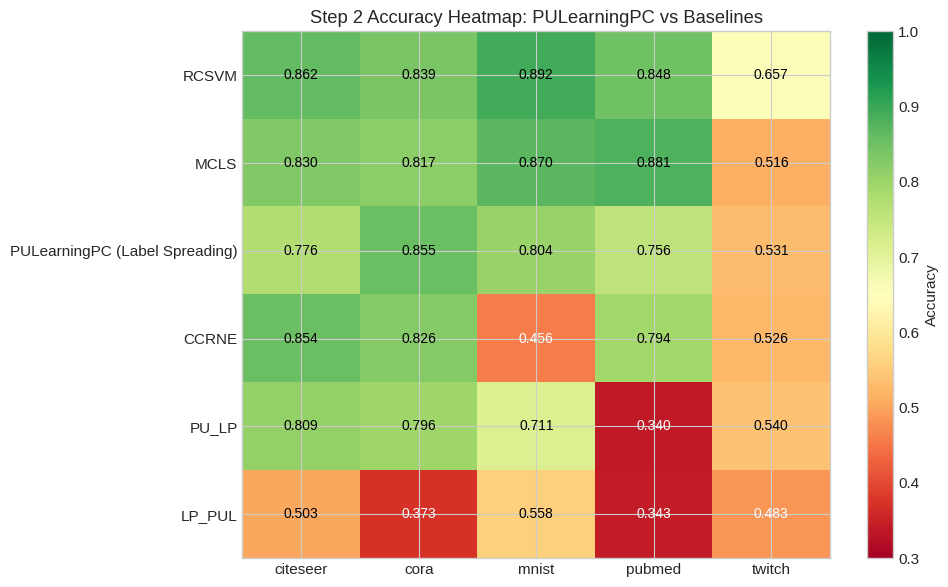

In [9]:
# Heatmap-style visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Sort datasets for consistent ordering
dataset_order = sorted(acc_pivot.columns[acc_pivot.columns != 'mean'].tolist())
model_order = acc_pivot.index.tolist()

data_matrix = acc_pivot[dataset_order].values

im = ax.imshow(data_matrix, cmap='RdYlGn', aspect='auto', vmin=0.3, vmax=1.0)

ax.set_xticks(range(len(dataset_order)))
ax.set_xticklabels(dataset_order)
ax.set_yticks(range(len(model_order)))
ax.set_yticklabels(model_order)

# Add text annotations
for i in range(len(model_order)):
    for j in range(len(dataset_order)):
        val = data_matrix[i, j]
        if not np.isnan(val):
            color = 'white' if val < 0.5 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', color=color, fontsize=10)

ax.set_title('Step 2 Accuracy Heatmap: PULearningPC vs Baselines')
plt.colorbar(im, ax=ax, label='Accuracy')
plt.tight_layout()
plt.show()

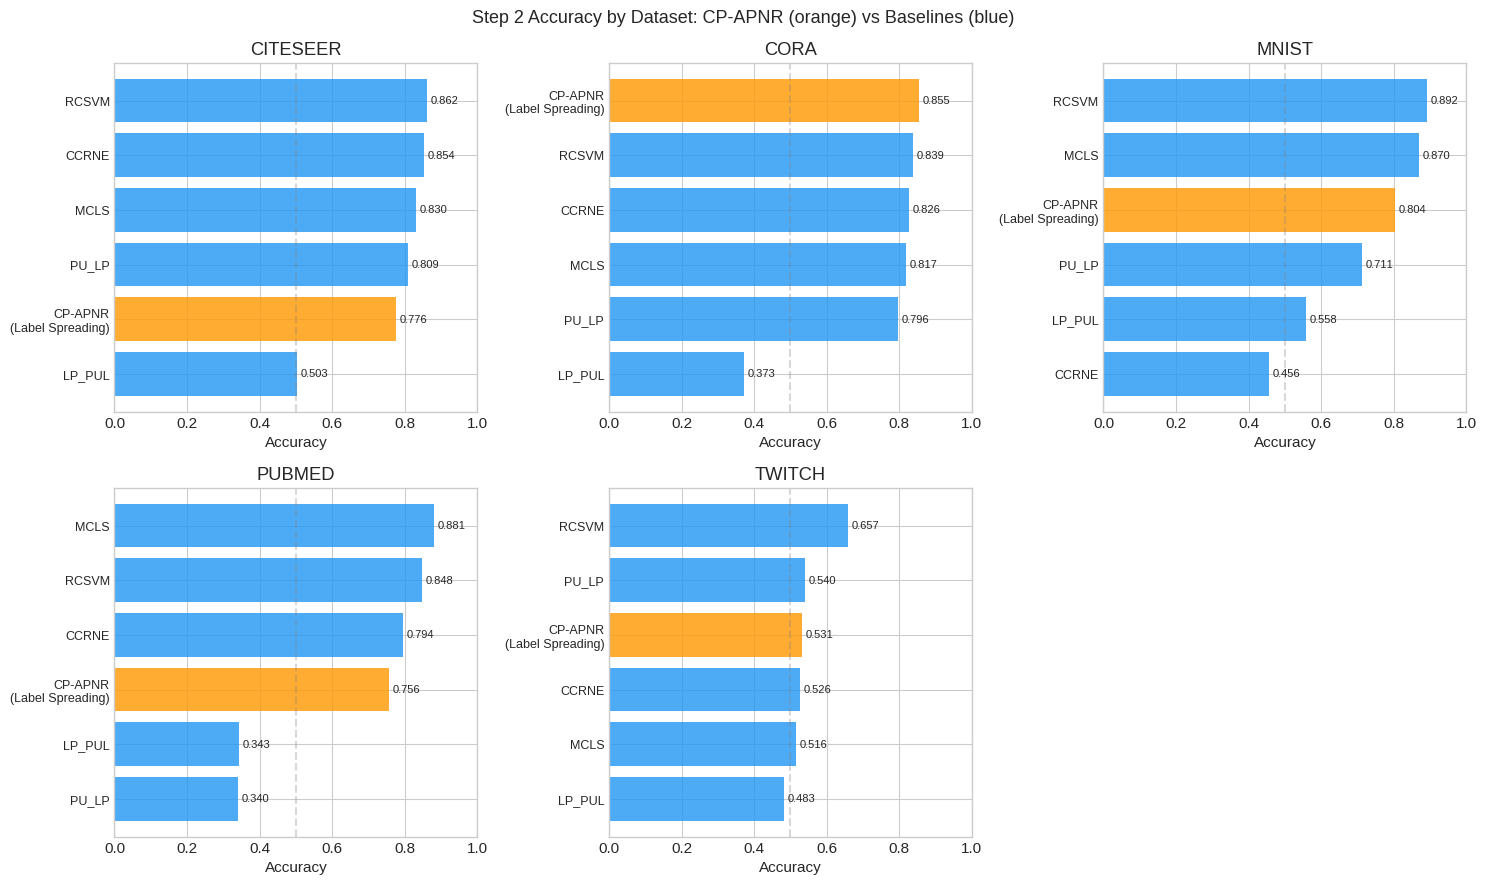

In [10]:
# Per-dataset bar chart with all models
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, ds in enumerate(dataset_order):
    ax = axes[idx]
    ds_data = df_all[df_all['dataset'] == ds].sort_values('accuracy', ascending=True)
    
    colors = ['#FF9800' if 'PULearningPC' in m else '#2196F3' for m in ds_data['model']]
    
    ax.barh(range(len(ds_data)), ds_data['accuracy'], color=colors, alpha=0.8)
    ax.set_yticks(range(len(ds_data)))
    ax.set_yticklabels(ds_data['model'].str.replace('PULearningPC ', 'CP-APNR\n'), fontsize=9)
    ax.set_xlabel('Accuracy')
    ax.set_title(f'{ds.upper()}')
    ax.set_xlim(0, 1)
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.3)
    
    for i, v in enumerate(ds_data['accuracy']):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)

# Hide unused subplot
if len(dataset_order) < len(axes):
    for i in range(len(dataset_order), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('Step 2 Accuracy by Dataset: CP-APNR (orange) vs Baselines (blue)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Critical Assessment

Key considerations for fair comparison:

In [11]:
# Check if num_neg (reliable negatives returned) is consistent across methods
print("=== num_neg (reliable negatives) consistency check ===")
print(f"\nBaseline phase1_num_rn values: {df_baseline['phase1_num_rn'].unique().tolist()}")
print(f"\nPULearningPC step1_num_reliable_negatives (LR, successful):")
print(df_lr_ok.groupby('dataset')['step1_num_reliable_negatives'].describe()[['mean', 'min', 'max']].round(0))
print(f"\nPULearningPC step1_num_reliable_negatives (LS, successful):")
print(df_ls_ok.groupby('dataset')['step1_num_reliable_negatives'].describe()[['mean', 'min', 'max']].round(0))

=== num_neg (reliable negatives) consistency check ===

Baseline phase1_num_rn values: [200, 300, 160, 8, 130, 123]

PULearningPC step1_num_reliable_negatives (LR, successful):
           mean    min    max
dataset                      
citeseer  200.0  200.0  200.0
cora      200.0  200.0  200.0
mnist     300.0  300.0  300.0
pubmed    200.0  200.0  200.0
twitch    200.0  200.0  200.0

PULearningPC step1_num_reliable_negatives (LS, successful):
           mean    min    max
dataset                      
citeseer  200.0  200.0  200.0
cora      200.0  200.0  200.0
mnist     300.0  300.0  300.0
pubmed    200.0  200.0  200.0
twitch    200.0  200.0  200.0


In [12]:
# Summary & recommendation
print("="*60)
print("SUMMARY")
print("="*60)
print(f"\n1. INTERNAL COMPARISON (LR vs LS):")
print(f"   Winner: {winner_name}")
print(f"   Mean accuracy — LR: {lr_mean:.4f}, LS: {ls_mean:.4f}")
print(f"   Advantage: {abs(ls_mean - lr_mean):.4f}")

print(f"\n2. VS BASELINES (25% positive setting):")
our_rank = list(acc_pivot.index).index(f'PULearningPC ({winner_name})') + 1
our_mean = acc_pivot.loc[f'PULearningPC ({winner_name})', 'mean']
best_baseline = acc_pivot.drop(f'PULearningPC ({winner_name})').iloc[0]
print(f"   Our rank: {our_rank}/{len(acc_pivot)}")
print(f"   Our mean accuracy: {our_mean:.4f}")
print(f"   Best baseline ({acc_pivot.drop(f'PULearningPC ({winner_name})').index[0]}): {best_baseline['mean']:.4f}")

print(f"\n3. DATASETS WHERE WE WIN:")
for ds in dataset_order:
    if ds in acc_pivot.columns:
        our_val = acc_pivot.loc[f'PULearningPC ({winner_name})', ds]
        best_other = acc_pivot.drop(f'PULearningPC ({winner_name})')[ds].max()
        status = '✓ WIN' if our_val > best_other else '✗ LOSE'
        print(f"   {ds}: {status} (ours={our_val:.4f}, best_baseline={best_other:.4f})")

SUMMARY

1. INTERNAL COMPARISON (LR vs LS):
   Winner: Label Spreading
   Mean accuracy — LR: 0.7086, LS: 0.7444
   Advantage: 0.0358

2. VS BASELINES (25% positive setting):
   Our rank: 3/6
   Our mean accuracy: 0.7444
   Best baseline (RCSVM): 0.8196

3. DATASETS WHERE WE WIN:
   citeseer: ✗ LOSE (ours=0.7757, best_baseline=0.8621)
   cora: ✓ WIN (ours=0.8550, best_baseline=0.8385)
   mnist: ✗ LOSE (ours=0.8042, best_baseline=0.8924)
   pubmed: ✗ LOSE (ours=0.7564, best_baseline=0.8808)
   twitch: ✗ LOSE (ours=0.5309, best_baseline=0.6573)
